# 🤖 Notebook 2: Entrenamiento del Modelo

Este notebook cubre:
- Carga de datos con DataLoaders
- Creación del modelo con Transfer Learning (MobileNetV2)
- Configuración del entrenamiento
- Entrenamiento con early stopping
- Guardado del modelo

In [1]:
# Imports
import sys
sys.path.append('..')

import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.dataset.dataset import create_dataloaders
from src.models.classifier import create_model
from src.models.train import train_model, EarlyStopping
from src.utils.helpers import load_config, plot_training_history

# Configuración
plt.rcParams['figure.figsize'] = (15, 5)

## 1. Configuración

In [2]:
# Cargar configuración
config = load_config('../config/config.yaml')

# Parámetros
BATCH_SIZE = config['training']['batch_size']
EPOCHS = config['training']['epochs']
LEARNING_RATE = config['training']['learning_rate']
IMAGE_SIZE = config['dataset']['image_size']
ARCHITECTURE = config['model']['architecture']

# Dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")
print(f"PyTorch version: {torch.__version__}")

Dispositivo: cpu
PyTorch version: 2.9.1+cpu


## 2. Carga de Datos

In [3]:
# Crear DataLoaders
train_loader, val_loader, test_loader, class_names = create_dataloaders(
    train_dir='../data/processed/train',
    val_dir='../data/processed/val',
    test_dir='../data/processed/test',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_workers=2,  # Ajustar según tu CPU
    augment=True
)

num_classes = len(class_names)
print(f"\nClases ({num_classes}):")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")


DataLoaders creados:
Train: 1775 imágenes (56 batches)
Val:   370 imágenes (12 batches)
Test:  413 imágenes (13 batches)
Batch size: 32
Clases: 32


Clases (32):
  0: Amruthaballi
  1: Mint
  2: Neem
  3: Nerale
  4: Nooni
  5: Onion
  6: Padri
  7: Palak(Spinach)
  8: Papaya
  9: Parijatha
  10: Pea
  11: Pepper
  12: Pomoegranate
  13: Pumpkin
  14: Raddish
  15: Rose
  16: Sampige
  17: Sapota
  18: Seethaashoka
  19: Seethapala
  20: Spinach1
  21: Tamarind
  22: Taro
  23: Tecoma
  24: Thumbe
  25: Tomato
  26: Tulsi
  27: Turmeric
  28: ashoka
  29: camphor
  30: kamakasturi
  31: kepala


## 3. Visualización de Datos Aumentados

c:\Users\Deivid Cardenas\Music\pruebas\venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


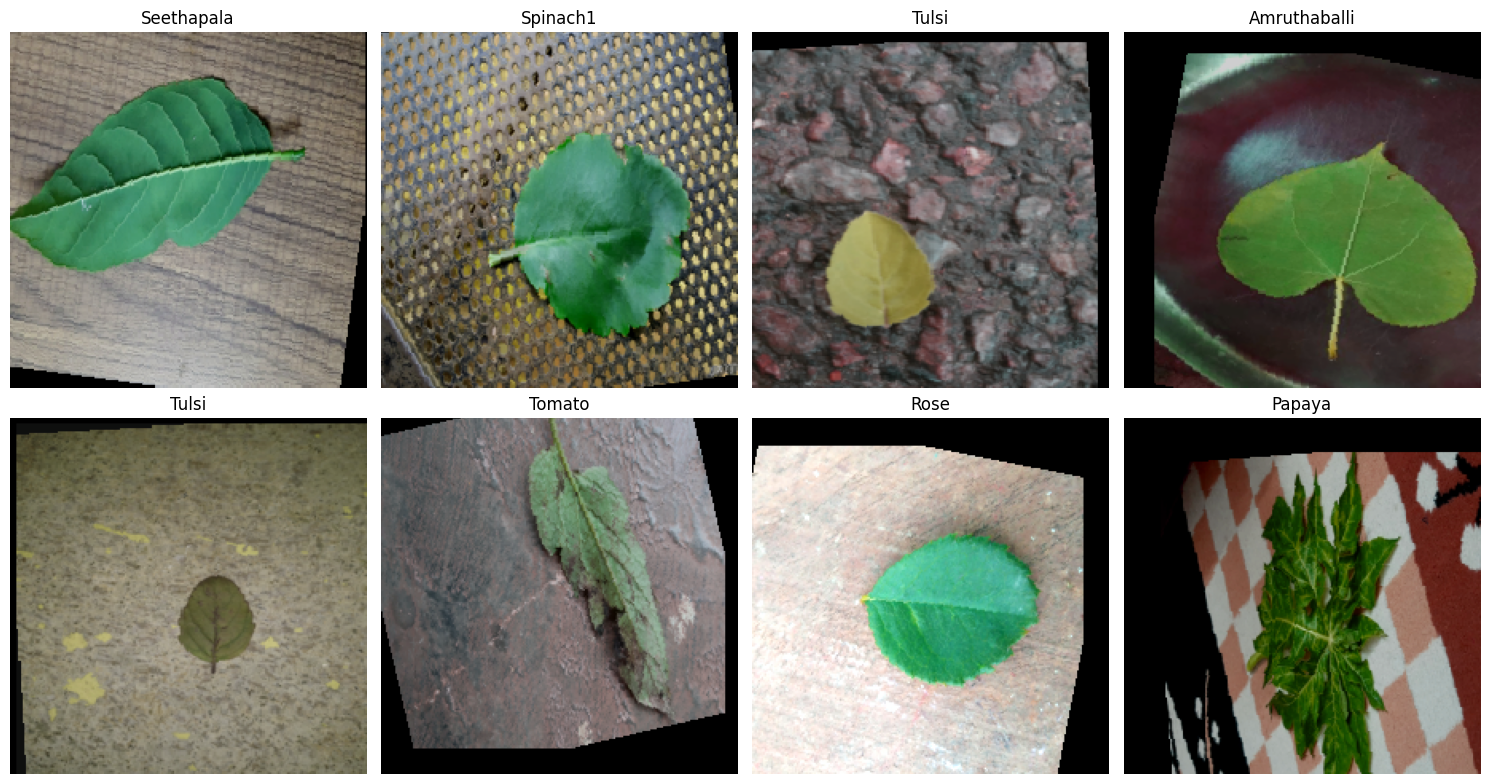

In [4]:
# Visualizar batch de entrenamiento
import torchvision
import numpy as np

def imshow(img, title=None):
    """Muestra una imagen de tensor."""
    # Desnormalizar
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Obtener un batch
images, labels = next(iter(train_loader))

# Mostrar grid
fig = plt.figure(figsize=(15, 8))
for i in range(min(8, len(images))):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images[i], title=class_names[labels[i]])

plt.tight_layout()
plt.show()

## 4. Creación del Modelo

In [5]:
# Crear modelo
model = create_model(
    num_classes=num_classes,
    architecture=ARCHITECTURE,
    pretrained=True,
    dropout=config['model']['dropout'],
    freeze_ratio=config['model']['freeze_ratio'],
    device=device
)


Creando modelo mobilenet_v2...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Deivid Cardenas/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


c:\Users\Deivid Cardenas\Music\pruebas\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Deivid Cardenas\Music\pruebas\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 53.5MB/s]

✓ Congeladas 110/158 capas (70.0%)

Resumen del Modelo: mobilenet_v2
Arquitectura base: mobilenet_v2
Número de clases: 32
Parámetros totales: 2,264,864
Parámetros entrenables: 1,784,736
Parámetros congelados: 480,128



## 5. Configuración del Entrenamiento

In [6]:
# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizador
if config['training']['optimizer'] == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
else:
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

# Learning rate scheduler
if config['training']['scheduler'] == 'step':
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=config['training']['step_size'],
        gamma=config['training']['gamma']
    )
else:
    scheduler = None

# Early stopping
early_stopping = None
if config['training']['early_stopping']['enabled']:
    early_stopping = EarlyStopping(
        patience=config['training']['early_stopping']['patience'],
        mode='min'
    )

print("Configuración de entrenamiento:")
print(f"  - Función de pérdida: CrossEntropyLoss")
print(f"  - Optimizador: {config['training']['optimizer']}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Scheduler: {config['training']['scheduler']}")
print(f"  - Early stopping: {config['training']['early_stopping']['enabled']}")

Configuración de entrenamiento:
  - Función de pérdida: CrossEntropyLoss
  - Optimizador: adam
  - Learning rate: 0.001
  - Scheduler: step
  - Early stopping: True


## 6. Entrenamiento

In [7]:
# Entrenar modelo
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=EPOCHS,
    device=device,
    scheduler=scheduler,
    early_stopping=early_stopping,
    checkpoint_dir='../models/checkpoints',
    class_names=class_names
)


Iniciando entrenamiento
Épocas: 50
Dispositivo: cpu
Learning rate: 0.001
Batch size: 32


Época [1/50]
----------------------------------------------------------------------


Train Loss: 1.5978 | Train Acc: 56.45%
Val Loss:   0.5183 | Val Acc:   84.32%
LR: 0.001000 | Tiempo: 92.3s
✓ Mejor modelo guardado (Val Acc: 84.32%)

Época [2/50]
----------------------------------------------------------------------


Train Loss: 0.4868 | Train Acc: 84.85%
Val Loss:   0.4349 | Val Acc:   86.76%
LR: 0.001000 | Tiempo: 89.7s
✓ Mejor modelo guardado (Val Acc: 86.76%)

Época [3/50]
----------------------------------------------------------------------


Train Loss: 0.3169 | Train Acc: 90.48%
Val Loss:   0.4421 | Val Acc:   85.95%
LR: 0.001000 | Tiempo: 88.7s

Época [4/50]
----------------------------------------------------------------------


Train Loss: 0.2420 | Train Acc: 92.79%
Val Loss:   0.3547 | Val Acc:   90.00%
LR: 0.001000 | Tiempo: 87.1s
✓ Mejor modelo guardado (Val Acc: 90.00%)

Época [5/50]
----------------------------------------------------------------------


...

Train Loss: 0.0166 | Train Acc: 99.66%
Val Loss:   0.1018 | Val Acc:   96.22%
LR: 0.000010 | Tiempo: 87.2s

Época [25/50]
----------------------------------------------------------------------


Train Loss: 0.0088 | Train Acc: 99.77%
Val Loss:   0.1044 | Val Acc:   96.49%
LR: 0.000010 | Tiempo: 87.7s

Época [26/50]
----------------------------------------------------------------------


Train Loss: 0.0115 | Train Acc: 99.89%
Val Loss:   0.1048 | Val Acc:   96.49%
LR: 0.000010 | Tiempo: 88.5s

Época [27/50]
----------------------------------------------------------------------


Train Loss: 0.0115 | Train Acc: 99.77%
Val Loss:   0.1114 | Val Acc:   96.49%
LR: 0.000010 | Tiempo: 87.9s

Época [28/50]
----------------------------------------------------------------------


Train Loss: 0.0107 | Train Acc: 99.83%
Val Loss:   0.0944 | Val Acc:   96.76%
LR: 0.000010 | Tiempo: 88.5s

⚠ Early stopping activado en época 28

Entrenamiento completado
Tiempo total: 0h 41m 16s
Mejor Val Acc: 97.30% (Época 13)



## 7. Visualización del Entrenamiento

Gráfica de entrenamiento guardada en: ../docs/training_history.png


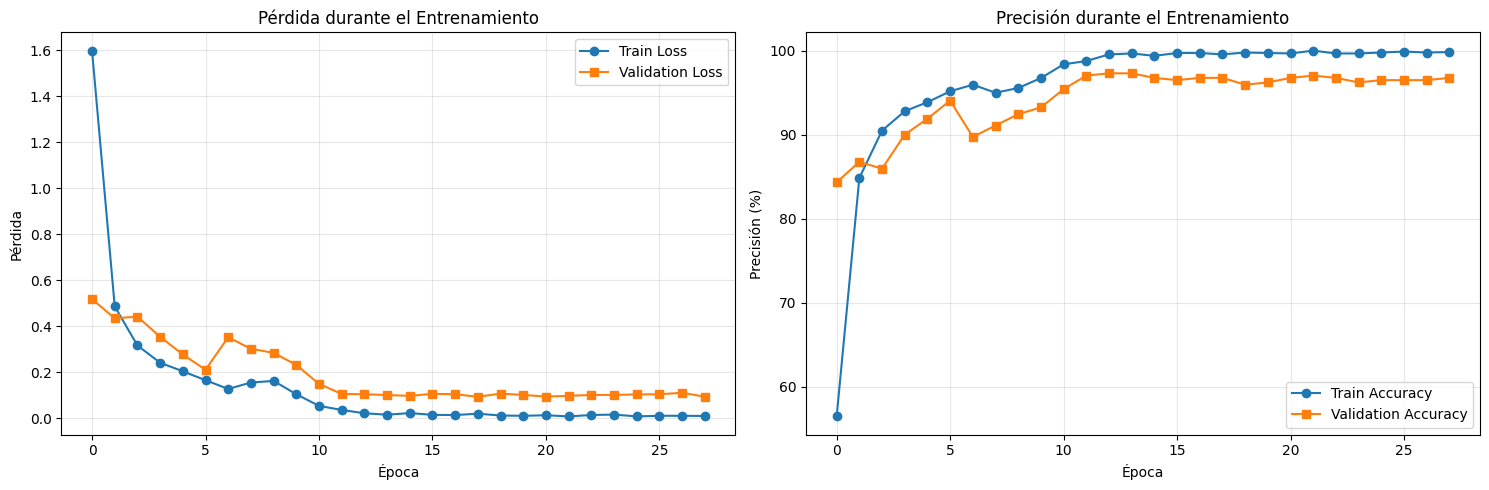

In [8]:
# Graficar historial de entrenamiento
plot_training_history(history, save_path='../docs/training_history.png')

## 8. Guardar Modelo Final

In [9]:
# Copiar el mejor modelo a la ubicación final
import shutil

best_model_path = '../models/checkpoints/best_model.pth'
final_model_path = '../models/best_model.pth'

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, final_model_path)
    print(f"✓ Modelo guardado en: {final_model_path}")
else:
    print("⚠ No se encontró el mejor modelo")

✓ Modelo guardado en: ../models/best_model.pth


## 9. Resumen del Entrenamiento

In [10]:
# Mostrar resumen
print("\n" + "="*70)
print("RESUMEN DEL ENTRENAMIENTO")
print("="*70)
print(f"Arquitectura: {ARCHITECTURE}")
print(f"Número de clases: {num_classes}")
print(f"Épocas entrenadas: {len(history['train_loss'])}")
print(f"Mejor Train Acc: {max(history['train_acc']):.2f}%")
print(f"Mejor Val Acc: {max(history['val_acc']):.2f}%")
print(f"Mejor Train Loss: {min(history['train_loss']):.4f}")
print(f"Mejor Val Loss: {min(history['val_loss']):.4f}")
print("="*70)


RESUMEN DEL ENTRENAMIENTO
Arquitectura: mobilenet_v2
Número de clases: 32
Épocas entrenadas: 28
Mejor Train Acc: 100.00%
Mejor Val Acc: 97.30%
Mejor Train Loss: 0.0086
Mejor Val Loss: 0.0941


## 10. Próximos Pasos

1. ✅ Modelo entrenado y guardado
2. ➡️ Continuar con `03_evaluacion_modelo.ipynb` para evaluar en el conjunto de test
3. ➡️ Probar el modelo en la aplicación Flask

In [11]:
print("\n✓ Entrenamiento completado")
print("\nPróximo paso: Abrir 03_evaluacion_modelo.ipynb")


✓ Entrenamiento completado

Próximo paso: Abrir 03_evaluacion_modelo.ipynb
